# Pingviini analüütika

## Seadistused

In [22]:
import pandas as pd
import duckdb

import matplotlib.pyplot as plt
import seaborn as sns

## Andmete laadmine

In [2]:
penguins = sns.load_dataset("penguins")
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [3]:
duckdb.sql("SUMMARIZE penguins").df()

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,species,VARCHAR,Adelie,Gentoo,3,None,None,None,None,None,344,0.00
1,island,VARCHAR,Biscoe,Torgersen,3,None,None,None,None,None,344,0.00
2,bill_length_mm,DOUBLE,32.1,59.6,186,43.92192982456142,5.459583713926537,39.2625,44.382000000000005,48.51875,344,0.58
3,bill_depth_mm,DOUBLE,13.1,21.5,80,17.151169590643278,1.974793156816781,15.565625,17.318,18.671875,344,0.58
4,flipper_length_mm,DOUBLE,172.0,231.0,51,200.91520467836258,14.061713679356952,190.0,197.06,213.46875,344,0.58
5,body_mass_g,DOUBLE,2700.0,6300.0,77,4201.754385964912,801.9545356980948,3552.34375,4030.5,4769.53125,344,0.58
6,sex,VARCHAR,Female,Male,2,None,None,None,None,None,344,3.20


In [4]:
penguins_not_null = penguins.dropna()
penguins_not_null

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [5]:
duckdb.sql("""
    SELECT
        island,
        species,
        count(*) AS count
    FROM penguins_not_null
    GROUP BY island, species
    ORDER BY island, species
""").df()

,island,species,count
0,Biscoe,Adelie,44
1,Biscoe,Gentoo,119
2,Dream,Adelie,55
3,Dream,Chinstrap,68
4,Torgersen,Adelie,47


In [6]:
duckdb.sql("""
    SELECT
        island,
        count(*) AS count
    FROM penguins_not_null
    GROUP BY island
    ORDER BY island
""").df()

,island,count
0,Biscoe,163
1,Dream,123
2,Torgersen,47


In [7]:
duckdb.sql("""
    SELECT
        species,
        count(*) AS count
    FROM penguins_not_null
    GROUP BY species
    ORDER BY species
""").df()

,species,count
0,Adelie,146
1,Chinstrap,68
2,Gentoo,119


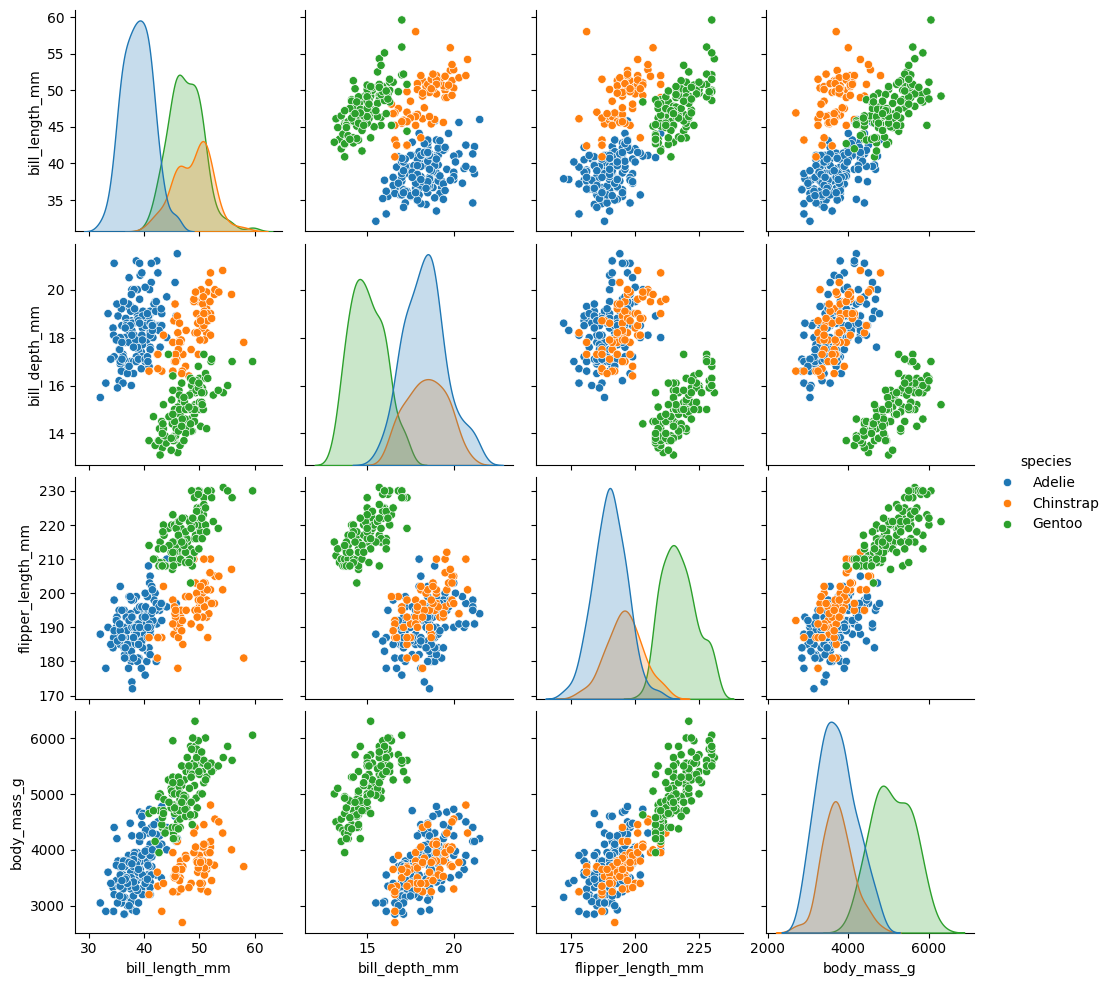

In [8]:
sns.pairplot(penguins_not_null, hue="species")

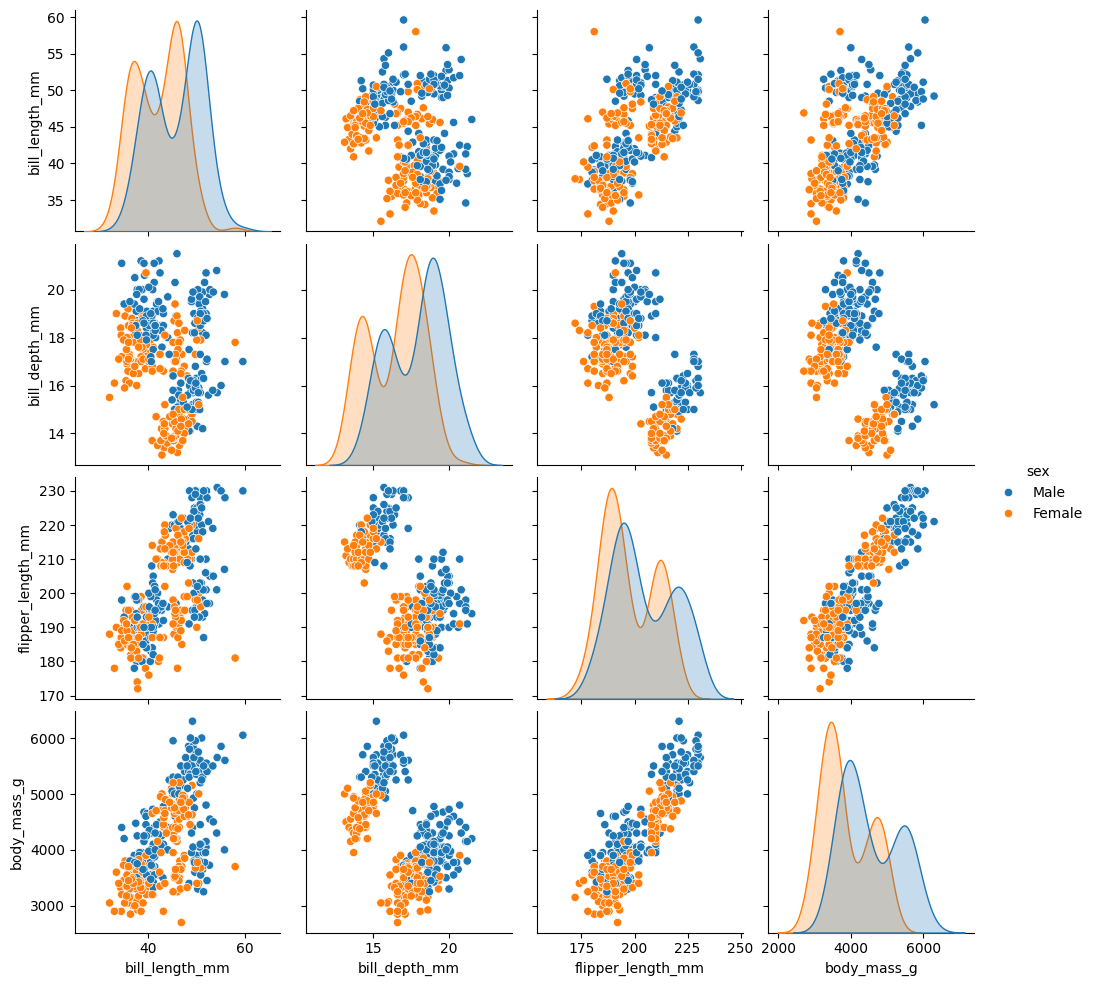

In [16]:
sns.pairplot(penguins_not_null, hue="sex")

<Axes: xlabel='body_mass_g', ylabel='species'>

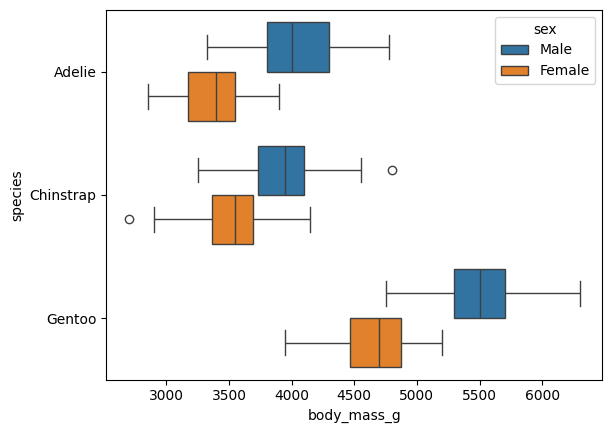

In [9]:
sns.boxplot(penguins_not_null, x="body_mass_g", y="species", hue="sex")

<Axes: xlabel='body_mass_g', ylabel='Density'>

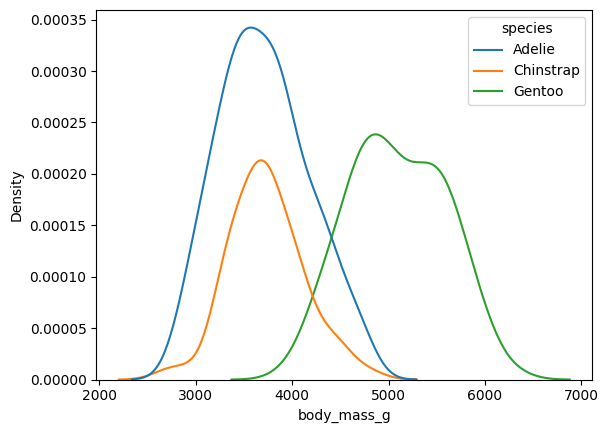

In [12]:
sns.kdeplot(penguins_not_null, x="body_mass_g", hue="species")

<Axes: xlabel='body_mass_g', ylabel='Density'>

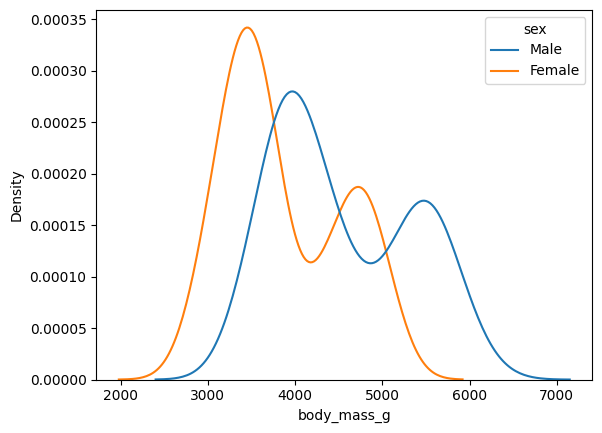

In [13]:
sns.kdeplot(penguins_not_null, x="body_mass_g", hue="sex")

In [15]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    duckdb.sql("SELECT body_mass_g FROM penguins_not_null WHERE species = 'Adelie'").df()["body_mass_g"],
    duckdb.sql("SELECT body_mass_g FROM penguins_not_null WHERE species = 'Chinstrap'").df()["body_mass_g"],
    alternative='two-sided'
)
float(p)
print(f"{p:.15f}")

0.547616848670757



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/eeriksp/Library/Python/3.9/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/eer

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/eeriksp/Library/Python/3.9/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/eer

AttributeError: _ARRAY_API not found

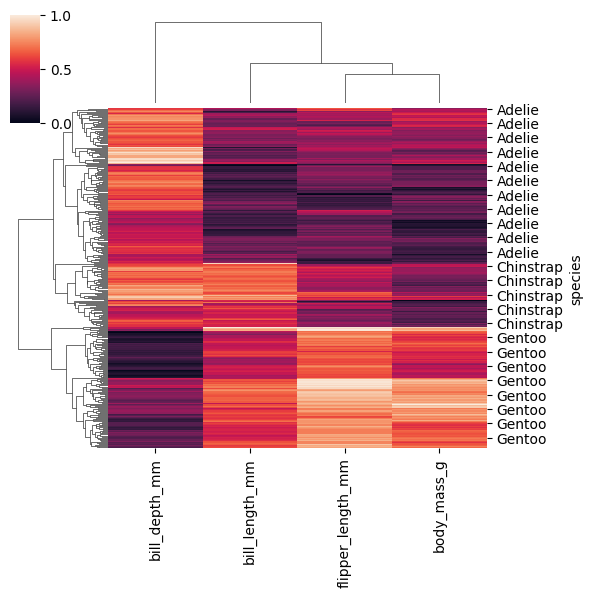

In [10]:
sns.clustermap(
    penguins_not_null[["bill_length_mm", "bill_depth_mm",
                       "flipper_length_mm", "body_mass_g", "species"]].set_index("species"),
    standard_scale=1,
    figsize=(6,6)
)

## Ennustamine

In [21]:
!pip3 install statsmodels

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [17]:
import statsmodels.formula.api as smf

penguins_not_null["sex_binary"] = (penguins_not_null["sex"] == "Male").astype(int)

model = smf.logit("sex_binary ~ body_mass_g + flipper_length_mm", data=penguins_not_null).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.558531
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             sex_binary   No. Observations:                  333
Model:                          Logit   Df Residuals:                      330
Method:                           MLE   Df Model:                            2
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                  0.1942
Time:                        14:32:21   Log-Likelihood:                -185.99
converged:                       True   LL-Null:                       -230.80
Covariance Type:            nonrobust   LLR p-value:                 3.449e-20
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             7.0868      2.662      2.662      0.008       1.869      12.305
body_mas

/var/folders/d5/v1n8g5qn4hvbs41713n9bhkw0000gn/T/ipykernel_72898/2295869997.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penguins_not_null["sex_binary"] = (penguins_not_null["sex"] == "Male").astype(int)


In [ ]:
new_data = pd.DataFrame({
    "body_mass_g": [4000, 3500, 5000],
    "flipper_length_mm": [200, 185, 210]
})
new_data["pred_prob"] = model.predict(new_data)
new_data["pred_class"] = (new_data["pred_prob"] > 0.5).astype(int)
new_data

,body_mass_g,flipper_length_mm,pred_prob,pred_class
0,4000,200,0.392569,0
1,3500,185,0.394442,0
2,5000,210,0.804225,1
